# Etapa 3 — Pipeline de detección y clasificación

Este notebook documenta y prueba la **Etapa 3** del TP: detección de perros en imágenes complejas y clasificación de cada perro detectado.

Flujo implementado:

1. Cargar una imagen.
2. Detectar perros con YOLO preentrenado.
3. Obtener bounding boxes.
4. Recortar cada perro detectado.
5. Clasificar cada crop con el modelo entrenado en la Etapa 2.
6. Visualizar la imagen original con bounding boxes, raza predicha y scores.

La consigna no requiere entrenar un detector propio; se utiliza YOLO preentrenado para localizar perros y el clasificador supervisado de la Etapa 2 para predecir la raza.


## 1. Instalación e imports

In [89]:
import sys
from pathlib import Path


IN_COLAB = "google.colab" in sys.modules


if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    ENVIRONMENT_ROOT = Path("/content")

    print("Entorno: Google Colab")
    print("Google Drive montado correctamente.")

else:
    ENVIRONMENT_ROOT = Path.cwd().resolve()

    print("Entorno: local")
    print(f"Directorio de trabajo: {ENVIRONMENT_ROOT}")

Entorno: local
Directorio de trabajo: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app


In [90]:
!pip -q install ultralytics

In [91]:
from pathlib import Path
from typing import List, Tuple, Dict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

from ultralytics import YOLO

print("Torch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

Torch: 2.11.0+cpu
CUDA disponible: False


## 2. Configuración general

Estos valores replican la configuración usada en el backend:

- `YOLO_MODEL`: modelo YOLO preentrenado.
- `YOLO_CONF_THRESHOLD`: umbral mínimo de confianza de detección.
- `YOLO_DOG_CLASS_ID`: clase `dog` en COCO.
- `IMAGE_SIZE`: tamaño de entrada esperado por el clasificador.
- `ACTIVE_MODEL`: clasificador entrenado en Etapa 2.

Como el checkpoint no suele subirse al repositorio por tamaño, se puede cargar desde Drive o subirlo manualmente al entorno de Colab.


In [92]:
import os
import sys
from pathlib import Path

import torch
from dotenv import load_dotenv


SRC_PATH = PROJECT_ROOT / "src"
ENV_PATH = SRC_PATH / ".env"


if not ENV_PATH.is_file():
    raise FileNotFoundError(
        f"No se encontró el archivo de configuración: {ENV_PATH}"
    )


load_dotenv(
    ENV_PATH,
    override=True,
)


if str(SRC_PATH) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_PATH),
    )


from lib.config import settings


def resolve_from_src(path: Path) -> Path:
    path = Path(path)

    if path.is_absolute():
        return path.resolve()

    return (SRC_PATH / path).resolve()


ACTIVE_MODEL = settings.classifier_model

YOLO_MODEL = settings.yolo_model
YOLO_CONF_THRESHOLD = settings.yolo_conf_threshold
YOLO_NMS_IOU_THRESHOLD = settings.yolo_nms_iou_threshold
YOLO_IMAGE_SIZE = settings.yolo_image_size
YOLO_DOG_CLASS_ID = settings.yolo_dog_class_id
DUPLICATE_OVERLAP_THRESHOLD = settings.duplicate_overlap_threshold

IMAGE_SIZE = settings.image_size

MODEL_PATH = resolve_from_src(
    settings.model_path
)


if ACTIVE_MODEL == "resnet18_finetuned":
    checkpoint_name = settings.resnet18_model_name

elif ACTIVE_MODEL == "cnn_custom":
    checkpoint_name = settings.cnn_custom_model_name

else:
    raise ValueError(
        f"CLASSIFIER_MODEL inválido: {ACTIVE_MODEL}"
    )


CHECKPOINT_PATH = MODEL_PATH / checkpoint_name


if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"No se encontró el checkpoint: {CHECKPOINT_PATH}"
    )


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Configuración:", ENV_PATH)
print("Device:", device)
print("Clasificador:", ACTIVE_MODEL)
print("Checkpoint:", CHECKPOINT_PATH)
print("YOLO:", YOLO_MODEL)
print("YOLO confidence:", YOLO_CONF_THRESHOLD)
print("YOLO image size:", YOLO_IMAGE_SIZE)

Configuración: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\src\.env
Device: cpu
Clasificador: resnet18_finetuned
Checkpoint: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\models\resnet18_finetuned.pth
YOLO: yolov8n.pt
YOLO confidence: 0.25
YOLO image size: 960


## 3. Carga del checkpoint de Etapa 2

El clasificador de la Etapa 3 depende del modelo entrenado en la Etapa 2.  
El checkpoint esperado debe contener:

- `model_state_dict`
- `class_names`
- `model_name`

Si el archivo no está en la ruta indicada, se puede subir manualmente desde la siguiente celda.


## 4. Arquitecturas compatibles con Etapa 2

Se reconstruyen las mismas arquitecturas usadas en `ClassifierService`:

- ResNet18 fine-tuned.
- CNN Custom.

Esto permite cargar el `state_dict` guardado durante la Etapa 2.


In [93]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_resnet18_finetuned(n_classes: int) -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

def build_cnn_custom(n_classes: int) -> nn.Module:
    model = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(256, n_classes),
    )
    return model.to(device)

inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def load_classifier(checkpoint_path: Path, active_model: str = ACTIVE_MODEL):
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"No existe el checkpoint: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    class_names = checkpoint["class_names"]
    n_classes = len(class_names)

    model_name = checkpoint.get("model_name", active_model)

    if model_name == "resnet18_finetuned":
        model = build_resnet18_finetuned(n_classes)
    elif model_name == "cnn_custom":
        model = build_cnn_custom(n_classes)
    else:
        raise ValueError(f"Modelo desconocido en checkpoint: {model_name}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, class_names, model_name

classifier_model, class_names, loaded_model_name = load_classifier(CHECKPOINT_PATH)

print("Modelo cargado:", loaded_model_name)
print("Cantidad de clases:", len(class_names))
print("Primeras clases:", class_names[:5])

Modelo cargado: resnet18_finetuned
Cantidad de clases: 70
Primeras clases: ['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel']


## 5. Carga del detector YOLO

Se utiliza YOLO preentrenado. No se entrena el detector porque la consigna pide usar un detector ya entrenado y concentrarse en integrar detección con clasificación de razas.


In [94]:
yolo_model = YOLO(YOLO_MODEL)
print("YOLO cargado:", YOLO_MODEL)

YOLO cargado: yolov8n.pt


## 6. Función `detect_dogs(image)`

Recibe una imagen en formato BGR, ejecuta YOLO, filtra la clase `dog` y devuelve bounding boxes con score de detección.


In [95]:
from typing import List, Tuple


Detection = Tuple[
    Tuple[int, int, int, int],
    float,
]


def clip_xyxy(
    x1: int,
    y1: int,
    x2: int,
    y2: int,
    height: int,
    width: int,
) -> Tuple[int, int, int, int]:
    x1 = max(0, min(x1, width - 1))
    x2 = max(0, min(x2, width))

    y1 = max(0, min(y1, height - 1))
    y2 = max(0, min(y2, height))

    if x2 <= x1:
        x2 = min(x1 + 1, width)

    if y2 <= y1:
        y2 = min(y1 + 1, height)

    return x1, y1, x2, y2


def overlap_over_smaller_box(
    box_a: Tuple[int, int, int, int],
    box_b: Tuple[int, int, int, int],
) -> float:
    """
    Calcula qué proporción de la caja más pequeña está cubierta
    por la intersección entre ambas cajas.
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)
    intersection_area = inter_width * inter_height

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    smaller_area = min(area_a, area_b)

    if smaller_area == 0:
        return 0.0

    return intersection_area / smaller_area


def remove_duplicate_detections(
    detections: List[Detection],
    overlap_threshold: float,
) -> List[Detection]:
    """
    Prioriza las cajas con mayor confianza y elimina otra caja
    cuando está casi completamente contenida en una ya conservada.
    """
    ordered_detections = sorted(
        detections,
        key=lambda detection: detection[1],
        reverse=True,
    )

    filtered_detections: List[Detection] = []

    for candidate_box, candidate_confidence in ordered_detections:
        duplicate = any(
            overlap_over_smaller_box(
                candidate_box,
                kept_box,
            )
            >= overlap_threshold
            for kept_box, _ in filtered_detections
        )

        if not duplicate:
            filtered_detections.append(
                (
                    candidate_box,
                    candidate_confidence,
                )
            )

    return filtered_detections


def detect_dogs(
    image_bgr: np.ndarray,
) -> List[Detection]:
    if image_bgr is None or image_bgr.size == 0:
        return []

    height, width = image_bgr.shape[:2]

    results = yolo_model.predict(
        source=image_bgr,
        conf=float(YOLO_CONF_THRESHOLD),
        iou=float(YOLO_NMS_IOU_THRESHOLD),
        imgsz=int(YOLO_IMAGE_SIZE),
        classes=[int(YOLO_DOG_CLASS_ID)],
        verbose=False,
    )

    if (
        not results
        or results[0].boxes is None
        or len(results[0].boxes) == 0
    ):
        return []

    raw_detections: List[Detection] = []

    for box in results[0].boxes:
        coordinates = (
            box.xyxy[0]
            .detach()
            .cpu()
            .numpy()
        )

        confidence = float(
            box.conf[0]
            .detach()
            .cpu()
            .item()
        )

        x1, y1, x2, y2 = [
            int(round(value))
            for value in coordinates
        ]

        clipped_box = clip_xyxy(
            x1,
            y1,
            x2,
            y2,
            height,
            width,
        )

        raw_detections.append(
            (
                clipped_box,
                confidence,
            )
        )

    filtered_detections = remove_duplicate_detections(
        detections=raw_detections,
        overlap_threshold=DUPLICATE_OVERLAP_THRESHOLD,
    )

    return filtered_detections

## 7. Función `classify_detected_dog(crop)`

Cada crop detectado por YOLO se convierte de BGR a RGB, se preprocesa igual que en la Etapa 2 y luego se clasifica con el modelo entrenado.


In [96]:
def classify_detected_dog(crop_bgr: np.ndarray) -> Tuple[str, float]:
    if crop_bgr is None or crop_bgr.size == 0:
        return "unknown", 0.0

    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(crop_rgb)

    tensor = inference_transform(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = classifier_model(tensor)
        probs = torch.softmax(outputs, dim=1)
        score, pred_idx = torch.max(probs, dim=1)

    breed = class_names[int(pred_idx.item())]
    confidence = float(score.item())

    return breed, confidence

## 8. Pipeline completo

Integra la etapa completa:

`imagen original → detección YOLO → recorte → clasificación de raza → visualización`.


In [97]:
def run_pipeline(image_path: str) -> Dict:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    height, width = image_bgr.shape[:2]
    detections = []

    for box, det_score in detect_dogs(image_bgr):
        x1, y1, x2, y2 = clip_xyxy(*box, height, width)
        crop = image_bgr[y1:y2, x1:x2]

        breed, breed_score = classify_detected_dog(crop)

        detections.append({
            "bbox": [x1, y1, x2, y2],
            "det_score": float(det_score),
            "breed": breed,
            "breed_score": float(breed_score),
        })

    return {
        "source_path": str(image_path),
        "detections": detections,
        "detected_breeds": sorted({d["breed"] for d in detections if d["breed"] != "unknown"}),
    }

def draw_detections(image_path: str, result: Dict, figsize=(10, 8)):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    annotated = image_rgb.copy()

    for det in result["detections"]:
        x1, y1, x2, y2 = det["bbox"]
        breed = det["breed"]
        det_score = det["det_score"]
        breed_score = det["breed_score"]

        label = f"{breed} | det={det_score:.2f} | cls={breed_score:.2f}"

        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            annotated,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=figsize)
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(f"Detecciones: {len(result['detections'])}")
    plt.show()

## 9. Imágenes de prueba

La consigna pide probar la etapa con:

- una imagen con un perro;
- una imagen con múltiples perros;
- una escena compleja con otros objetos.

Si las imágenes ya están en Drive o en el repo, completar `TEST_IMAGE_PATHS`.  
Si no, ejecutar la celda de subida manual.


In [98]:
import shutil
from pathlib import Path

import gdown


# ------------------------------------------------------------
# Conjunto específico de evaluación para la Etapa 3
# ------------------------------------------------------------

ETAPA3_FOLDER_URL = (
    "https://drive.google.com/drive/folders/"
    "1y3Brcia5vRHMDLFzVZK6GrpkDjBrEvws"
)

ETAPA3_EVAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "external_eval"
    / "eval_etapa3"
)

EXPECTED_TEST_IMAGES = [
    "01_one_dog.png",
    "02_multiple_dogs.jpeg",
    "03_complex_scene.jpg",
]


def find_expected_images(
    root: Path,
    expected_names: list[str],
) -> dict[str, Path]:
    """
    Busca recursivamente las imágenes esperadas porque gdown
    puede conservar el nombre original de la carpeta de Drive.
    """
    found = {}

    if not root.exists():
        return found

    for path in root.rglob("*"):
        if (
            path.is_file()
            and path.name in expected_names
        ):
            found[path.name] = path.resolve()

    return found


# ------------------------------------------------------------
# Reutilizar archivos existentes o descargar la carpeta
# ------------------------------------------------------------

found_images = find_expected_images(
    ETAPA3_EVAL_PATH,
    EXPECTED_TEST_IMAGES,
)

missing_images = [
    filename
    for filename in EXPECTED_TEST_IMAGES
    if filename not in found_images
]


if missing_images:
    print(
        "No están disponibles todas las imágenes. "
        "Se descargará la carpeta desde Google Drive."
    )

    shutil.rmtree(
        ETAPA3_EVAL_PATH,
        ignore_errors=True,
    )

    ETAPA3_EVAL_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    try:
        gdown.download_folder(
            url=ETAPA3_FOLDER_URL,
            output=str(ETAPA3_EVAL_PATH),
            quiet=False,
        )

    except Exception as error:
        raise RuntimeError(
            "No se pudo descargar la carpeta de evaluación. "
            "Verificá que el acceso de Drive esté configurado "
            "como 'Cualquier persona con el enlace'."
        ) from error

    found_images = find_expected_images(
        ETAPA3_EVAL_PATH,
        EXPECTED_TEST_IMAGES,
    )


# ------------------------------------------------------------
# Validación del contenido descargado
# ------------------------------------------------------------

missing_images = [
    filename
    for filename in EXPECTED_TEST_IMAGES
    if filename not in found_images
]

if missing_images:
    raise FileNotFoundError(
        "Faltan imágenes obligatorias de la Etapa 3: "
        f"{missing_images}. "
        "Revisá los nombres de los archivos dentro de Drive."
    )


# Mantener el orden de los tres escenarios de la consigna.
TEST_IMAGE_PATHS = [
    str(found_images[filename])
    for filename in EXPECTED_TEST_IMAGES
]

# Se conserva este nombre para evitar romper celdas posteriores.
EXTERNAL_SET_PATH = ETAPA3_EVAL_PATH


print("Imágenes de evaluación de la Etapa 3:")

for scenario_number, image_path in enumerate(
    TEST_IMAGE_PATHS,
    start=1,
):
    print(
        f"{scenario_number}. {image_path}"
    )

Imágenes de evaluación de la Etapa 3:
1. C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\01_one_dog.png
2. C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\02_multiple_dogs.jpeg
3. C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\03_complex_scene.jpg


## 10. Ejecución sobre imágenes de prueba

Imagen: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\01_one_dog.png
Cantidad de perros detectados: 1
Razas detectadas: ['Doberman']


,bbox,det_score,breed,breed_score
0,"[164, 68, 383, 289]",0.96904,Doberman,0.986684


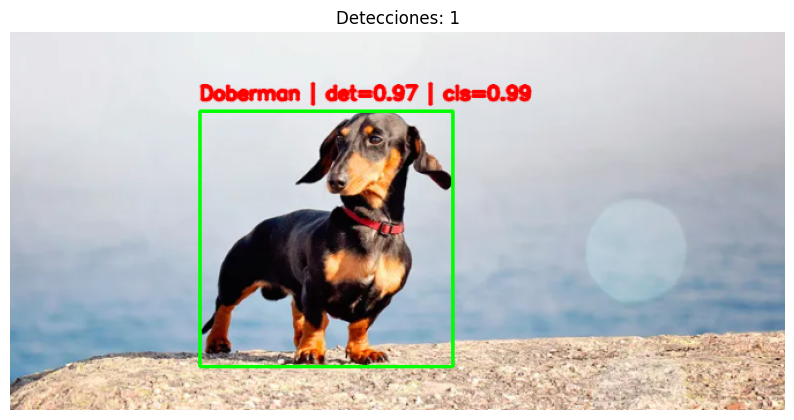

Imagen: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\02_multiple_dogs.jpeg
Cantidad de perros detectados: 5
Razas detectadas: ['Border Collie', 'Chihuahua', 'German Sheperd', 'Labrador', 'Maltese']


,bbox,det_score,breed,breed_score
0,"[829, 431, 951, 633]",0.942487,Chihuahua,0.988921
1,"[84, 204, 252, 617]",0.931901,Labrador,0.910539
2,"[459, 439, 643, 648]",0.912924,Maltese,0.998323
3,"[281, 151, 574, 580]",0.912575,German Sheperd,0.993865
4,"[611, 264, 831, 613]",0.904109,Border Collie,0.990907


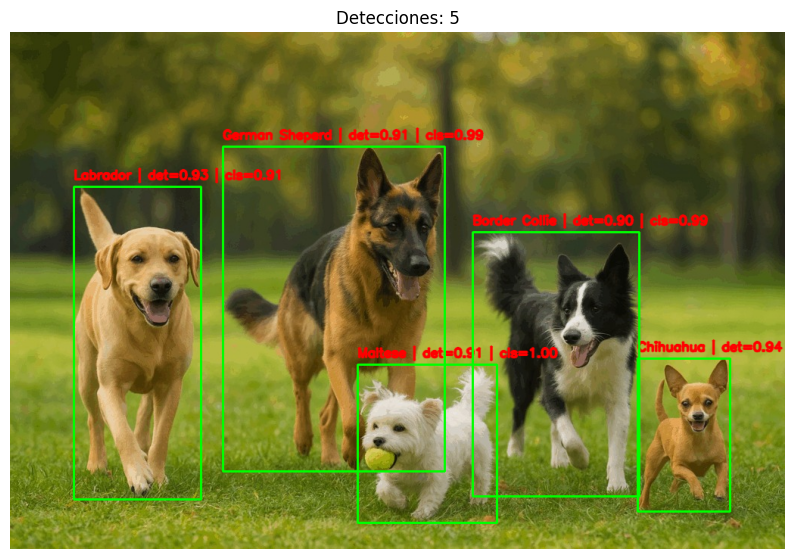

Imagen: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\eval_etapa3\03_complex_scene.jpg
Cantidad de perros detectados: 3
Razas detectadas: ['Beagle', 'Cockapoo', 'Pug']


,bbox,det_score,breed,breed_score
0,"[732, 1531, 1088, 2206]",0.621410,Cockapoo,0.378280
1,"[2075, 1602, 2938, 2636]",0.499890,Beagle,0.727322
2,"[986, 1676, 1994, 2369]",0.265167,Pug,0.210708


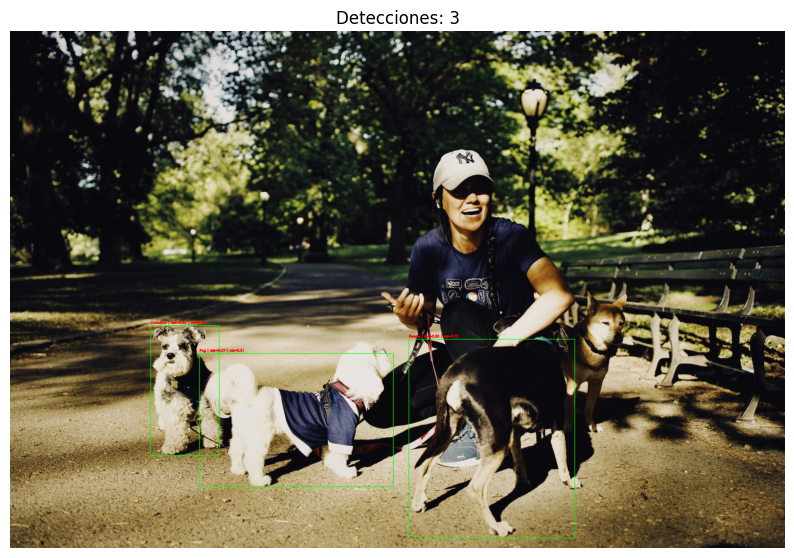

In [99]:
import pandas as pd
from IPython.display import display

all_results = []

for image_path in TEST_IMAGE_PATHS:
    print("=" * 80)
    print("Imagen:", image_path)

    result = run_pipeline(image_path)
    all_results.append(result)

    print("Cantidad de perros detectados:", len(result["detections"]))
    print("Razas detectadas:", result["detected_breeds"])
    display(pd.DataFrame(result["detections"]))

    draw_detections(image_path, result)

## 11. Resumen de resultados

In [100]:
summary_rows = []

for result in all_results:
    for i, det in enumerate(result["detections"], start=1):
        summary_rows.append({
            "source_path": result["source_path"],
            "dog_id": i,
            "bbox": det["bbox"],
            "det_score": round(det["det_score"], 4),
            "breed": det["breed"],
            "breed_score": round(det["breed_score"], 4),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,source_path,dog_id,bbox,det_score,breed,breed_score
0,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,1,"[164, 68, 383, 289]",0.9690,Doberman,0.9867
1,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,1,"[829, 431, 951, 633]",0.9425,Chihuahua,0.9889
2,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,2,"[84, 204, 252, 617]",0.9319,Labrador,0.9105
3,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,3,"[459, 439, 643, 648]",0.9129,Maltese,0.9983
4,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,4,"[281, 151, 574, 580]",0.9126,German Sheperd,0.9939
5,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,5,"[611, 264, 831, 613]",0.9041,Border Collie,0.9909
6,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,1,"[732, 1531, 1088, 2206]",0.6214,Cockapoo,0.3783
7,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,2,"[2075, 1602, 2938, 2636]",0.4999,Beagle,0.7273
8,C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognit...,3,"[986, 1676, 1994, 2369]",0.2652,Pug,0.2107


In [101]:
# Cantidad real de perros observados en cada imagen de prueba.
EXPECTED_DOG_COUNTS = {
    "01_one_dog.png": 1,
    "02_multiple_dogs.jpeg": 5,
    "03_complex_scene.jpg": 4,
}

SCENARIO_NAMES = {
    "01_one_dog.png": "Un perro",
    "02_multiple_dogs.jpeg": "Múltiples perros",
    "03_complex_scene.jpg": "Escena compleja",
}


evaluation_rows = []

for result in all_results:
    filename = Path(result["source_path"]).name

    if filename not in EXPECTED_DOG_COUNTS:
        continue

    expected = EXPECTED_DOG_COUNTS[filename]
    detected = len(result["detections"])

    detected_up_to_expected = min(
        detected,
        expected,
    )

    missed = max(
        expected - detected,
        0,
    )

    extra = max(
        detected - expected,
        0,
    )

    coverage = (
        detected_up_to_expected / expected
        if expected > 0
        else 0.0
    )

    if detected == expected:
        status = "Completo"
    elif detected < expected:
        status = "Parcial"
    else:
        status = "Detecciones adicionales"

    evaluation_rows.append(
        {
            "escenario": SCENARIO_NAMES[filename],
            "archivo": filename,
            "perros_reales": expected,
            "perros_detectados": detected,
            "perros_no_detectados": missed,
            "detecciones_adicionales": extra,
            "cobertura_por_conteo": coverage,
            "resultado": status,
        }
    )


detection_evaluation_df = pd.DataFrame(
    evaluation_rows
)

display(detection_evaluation_df)


total_expected = int(
    detection_evaluation_df[
        "perros_reales"
    ].sum()
)

total_covered = int(
    (
        detection_evaluation_df[
            "perros_reales"
        ]
        - detection_evaluation_df[
            "perros_no_detectados"
        ]
    ).sum()
)

total_missed = int(
    detection_evaluation_df[
        "perros_no_detectados"
    ].sum()
)

total_extra = int(
    detection_evaluation_df[
        "detecciones_adicionales"
    ].sum()
)

overall_coverage = (
    total_covered / total_expected
    if total_expected > 0
    else 0.0
)


print(
    "Cobertura global de detección por conteo: "
    f"{total_covered}/{total_expected} "
    f"= {overall_coverage:.2%}"
)

print(
    f"Perros no detectados: {total_missed}"
)

print(
    f"Detecciones adicionales: {total_extra}"
)

print()
print(
    "Esta medición evalúa únicamente la cantidad de perros "
    "detectados. No mide la calidad del bounding box ni la "
    "exactitud de la raza predicha."
)

,escenario,archivo,perros_reales,perros_detectados,perros_no_detectados,detecciones_adicionales,cobertura_por_conteo,resultado
0,Un perro,01_one_dog.png,1,1,0,0,1.00,Completo
1,Múltiples perros,02_multiple_dogs.jpeg,5,5,0,0,1.00,Completo
2,Escena compleja,03_complex_scene.jpg,4,3,1,0,0.75,Parcial


Cobertura global de detección por conteo: 9/10 = 90.00%
Perros no detectados: 1
Detecciones adicionales: 0

Esta medición evalúa únicamente la cantidad de perros detectados. No mide la calidad del bounding box ni la exactitud de la raza predicha.


In [102]:
from IPython.display import Markdown, display


if loaded_model_name == "resnet18_finetuned":
    model_description = """
Se utilizó **ResNet18 con fine-tuning parcial**, correspondiente al modelo que
obtuvo el mejor rendimiento durante la evaluación de la Etapa 2. La red parte
de pesos preentrenados en ImageNet, mantiene congeladas las primeras capas y
ajusta el último bloque convolucional y la capa de clasificación para las
70 razas del dataset.

Esta elección prioriza la calidad de clasificación frente al menor tamaño y
menor costo computacional de la CNN propia.
"""

elif loaded_model_name == "cnn_custom":
    model_description = """
Se utilizó la **CNN Custom entrenada desde cero** durante la Etapa 2. Esta
arquitectura es más compacta que ResNet18, pero no aprovecha características
previamente aprendidas sobre ImageNet y obtuvo un rendimiento inferior en la
evaluación realizada.
"""

else:
    model_description = (
        f"Se cargó el modelo **{loaded_model_name}**. "
        "La arquitectura no está documentada en esta notebook."
    )


display(
    Markdown(
        f"""
## Modelo utilizado en esta ejecución

Checkpoint cargado: `{CHECKPOINT_PATH.name}`

Modelo identificado dentro del checkpoint:
**`{loaded_model_name}`**

{model_description}

Para cada bounding box generado por YOLO, el recorte se transforma al tamaño
de entrada del clasificador, se normaliza con la media y desviación estándar de
ImageNet y se procesa con el modelo seleccionado.

El valor `breed_score` corresponde a la mayor probabilidad obtenida después de
aplicar Softmax a las salidas del clasificador. Este valor expresa la confianza
relativa del modelo entre las 70 clases, pero una confianza elevada no garantiza
que la raza predicha sea correcta.

El score de clasificación debe distinguirse de `det_score`: `det_score`
representa la confianza de YOLO en que la región contiene un perro, mientras
que `breed_score` representa la confianza del clasificador sobre la raza del
recorte detectado.
"""
    )
)


## Modelo utilizado en esta ejecución

Checkpoint cargado: `resnet18_finetuned.pth`

Modelo identificado dentro del checkpoint:
**`resnet18_finetuned`**


Se utilizó **ResNet18 con fine-tuning parcial**, correspondiente al modelo que
obtuvo el mejor rendimiento durante la evaluación de la Etapa 2. La red parte
de pesos preentrenados en ImageNet, mantiene congeladas las primeras capas y
ajusta el último bloque convolucional y la capa de clasificación para las
70 razas del dataset.

Esta elección prioriza la calidad de clasificación frente al menor tamaño y
menor costo computacional de la CNN propia.


Para cada bounding box generado por YOLO, el recorte se transforma al tamaño
de entrada del clasificador, se normaliza con la media y desviación estándar de
ImageNet y se procesa con el modelo seleccionado.

El valor `breed_score` corresponde a la mayor probabilidad obtenida después de
aplicar Softmax a las salidas del clasificador. Este valor expresa la confianza
relativa del modelo entre las 70 clases, pero una confianza elevada no garantiza
que la raza predicha sea correcta.

El score de clasificación debe distinguirse de `det_score`: `det_score`
representa la confianza de YOLO en que la región contiene un perro, mientras
que `breed_score` representa la confianza del clasificador sobre la raza del
recorte detectado.


In [103]:
from IPython.display import Markdown, display


evaluation_by_file = detection_evaluation_df.set_index("archivo")

one_dog_row = evaluation_by_file.loc["01_one_dog.png"]
multiple_dogs_row = evaluation_by_file.loc["02_multiple_dogs.jpeg"]
complex_scene_row = evaluation_by_file.loc["03_complex_scene.jpg"]


display(
    Markdown(
        f"""
## 12. Análisis de la Etapa 3

El pipeline se dividió en dos tareas consecutivas:

1. **YOLOv8n** localiza las regiones que contienen perros.
2. **{loaded_model_name}** clasifica la raza de cada recorte detectado.

Esta separación es necesaria porque el clasificador de la Etapa 2 fue
entrenado con imágenes centradas en un perro. Aplicarlo directamente sobre
una escena completa introduciría fondo, objetos irrelevantes o varios perros
dentro de una misma entrada.

### Resultados de detección

- **Un perro:** se detectaron
  **{int(one_dog_row["perros_detectados"])}/{int(one_dog_row["perros_reales"])}**.
- **Múltiples perros:** se detectaron
  **{int(multiple_dogs_row["perros_detectados"])}/{int(multiple_dogs_row["perros_reales"])}**.
- **Escena compleja:** se detectaron
  **{int(complex_scene_row["perros_detectados"])}/{int(complex_scene_row["perros_reales"])}**.

La cobertura global por conteo fue de **{overall_coverage:.2%}**. Se registraron
**{total_missed} perros no detectados** y **{total_extra} detecciones
adicionales**.

Las detecciones duplicadas observadas inicialmente fueron eliminadas mediante
un posprocesamiento que conserva primero las cajas de mayor confianza y
descarta aquellas casi completamente contenidas dentro de otra detección.

Para mejorar la detección de animales pequeños o alejados, YOLO se ejecutó con
una resolución de entrada de **{YOLO_IMAGE_SIZE} píxeles**, manteniendo un
umbral de confianza de **{YOLO_CONF_THRESHOLD:.2f}**.

La escena compleja continúa siendo el caso más difícil. El perro no detectado
aparece en una región con menor tamaño, mayor distancia u oclusión, condiciones
en las que un detector general preentrenado puede producir falsos negativos.
Este resultado se conserva como una limitación real del modelo y no se fuerza
una detección perfecta mediante una reducción excesiva del umbral.

### Scores del pipeline

El valor `det_score` expresa la confianza de YOLO en que la región contiene un
perro. El valor `breed_score` expresa la confianza del clasificador entre las
70 razas conocidas.

Ambos valores evalúan tareas diferentes. Una detección con `det_score` alto
puede recibir una raza incorrecta, y un `breed_score` elevado no garantiza que
la predicción sea correcta, especialmente cuando la imagen difiere del dominio
de entrenamiento o la raza real no está bien representada.

La medición de cobertura utilizada en esta sección evalúa solamente la cantidad
de perros detectados. No constituye una métrica de calidad de los bounding
boxes ni una accuracy de clasificación de razas.
"""
    )
)


## 12. Análisis de la Etapa 3

El pipeline se dividió en dos tareas consecutivas:

1. **YOLOv8n** localiza las regiones que contienen perros.
2. **resnet18_finetuned** clasifica la raza de cada recorte detectado.

Esta separación es necesaria porque el clasificador de la Etapa 2 fue
entrenado con imágenes centradas en un perro. Aplicarlo directamente sobre
una escena completa introduciría fondo, objetos irrelevantes o varios perros
dentro de una misma entrada.

### Resultados de detección

- **Un perro:** se detectaron
  **1/1**.
- **Múltiples perros:** se detectaron
  **5/5**.
- **Escena compleja:** se detectaron
  **3/4**.

La cobertura global por conteo fue de **90.00%**. Se registraron
**1 perros no detectados** y **0 detecciones
adicionales**.

Las detecciones duplicadas observadas inicialmente fueron eliminadas mediante
un posprocesamiento que conserva primero las cajas de mayor confianza y
descarta aquellas casi completamente contenidas dentro de otra detección.

Para mejorar la detección de animales pequeños o alejados, YOLO se ejecutó con
una resolución de entrada de **960 píxeles**, manteniendo un
umbral de confianza de **0.25**.

La escena compleja continúa siendo el caso más difícil. El perro no detectado
aparece en una región con menor tamaño, mayor distancia u oclusión, condiciones
en las que un detector general preentrenado puede producir falsos negativos.
Este resultado se conserva como una limitación real del modelo y no se fuerza
una detección perfecta mediante una reducción excesiva del umbral.

### Scores del pipeline

El valor `det_score` expresa la confianza de YOLO en que la región contiene un
perro. El valor `breed_score` expresa la confianza del clasificador entre las
70 razas conocidas.

Ambos valores evalúan tareas diferentes. Una detección con `det_score` alto
puede recibir una raza incorrecta, y un `breed_score` elevado no garantiza que
la predicción sea correcta, especialmente cuando la imagen difiere del dominio
de entrenamiento o la raza real no está bien representada.

La medición de cobertura utilizada en esta sección evalúa solamente la cantidad
de perros detectados. No constituye una métrica de calidad de los bounding
boxes ni una accuracy de clasificación de razas.


In [104]:
from IPython.display import Markdown, display


display(
    Markdown(
        f"""
## 13. Conclusión

En la Etapa 3 se implementó el pipeline completo solicitado:

1. **YOLOv8n** detecta los perros presentes en la imagen.
2. Se generan y ajustan los bounding boxes.
3. Se eliminan detecciones duplicadas del mismo animal.
4. Se recorta cada región detectada.
5. El modelo **{loaded_model_name}** clasifica la raza de cada recorte.
6. Se muestran sobre la imagen original la raza predicha, el score de
   detección y el score de clasificación.

La utilización de un detector YOLO preentrenado responde a lo indicado en la
consigna, que no requiere entrenar un detector propio. El modelo se configuró
con un umbral de confianza de **{YOLO_CONF_THRESHOLD:.2f}** y una resolución
de entrada de **{YOLO_IMAGE_SIZE} píxeles**.

El pipeline fue probado sobre los tres escenarios requeridos:

- una imagen con un solo perro;
- una imagen con múltiples perros;
- una escena compleja con otros objetos.

La cobertura global de detección fue de **{total_covered}/{total_expected}
({overall_coverage:.2%})**. En la escena compleja se detectaron tres de los
cuatro perros visibles. El perro omitido constituye un falso negativo asociado
a un escenario más difícil, con menor tamaño, distancia, oclusión o mayor
cantidad de elementos en la imagen.

Durante las primeras pruebas también se observaron varias cajas sobre un mismo
perro. Este problema se corrigió mediante un posprocesamiento que conserva la
detección de mayor confianza y elimina cajas prácticamente contenidas dentro
de otra detección.

Los resultados muestran que el pipeline funciona correctamente en escenarios
simples y con múltiples perros, mientras que las escenas complejas permiten
identificar límites reales del detector. No se afirma un funcionamiento
perfecto: el rendimiento final depende tanto de que YOLO localice correctamente
cada animal como de que el clasificador asigne correctamente la raza al recorte.

En conclusión, se cumplió el flujo requerido de detección, recorte,
clasificación y visualización. La principal limitación observada fue la pérdida
de una detección en la escena compleja, resultado que se conserva y documenta
como parte del análisis experimental.
"""
    )
)


## 13. Conclusión

En la Etapa 3 se implementó el pipeline completo solicitado:

1. **YOLOv8n** detecta los perros presentes en la imagen.
2. Se generan y ajustan los bounding boxes.
3. Se eliminan detecciones duplicadas del mismo animal.
4. Se recorta cada región detectada.
5. El modelo **resnet18_finetuned** clasifica la raza de cada recorte.
6. Se muestran sobre la imagen original la raza predicha, el score de
   detección y el score de clasificación.

La utilización de un detector YOLO preentrenado responde a lo indicado en la
consigna, que no requiere entrenar un detector propio. El modelo se configuró
con un umbral de confianza de **0.25** y una resolución
de entrada de **960 píxeles**.

El pipeline fue probado sobre los tres escenarios requeridos:

- una imagen con un solo perro;
- una imagen con múltiples perros;
- una escena compleja con otros objetos.

La cobertura global de detección fue de **9/10
(90.00%)**. En la escena compleja se detectaron tres de los
cuatro perros visibles. El perro omitido constituye un falso negativo asociado
a un escenario más difícil, con menor tamaño, distancia, oclusión o mayor
cantidad de elementos en la imagen.

Durante las primeras pruebas también se observaron varias cajas sobre un mismo
perro. Este problema se corrigió mediante un posprocesamiento que conserva la
detección de mayor confianza y elimina cajas prácticamente contenidas dentro
de otra detección.

Los resultados muestran que el pipeline funciona correctamente en escenarios
simples y con múltiples perros, mientras que las escenas complejas permiten
identificar límites reales del detector. No se afirma un funcionamiento
perfecto: el rendimiento final depende tanto de que YOLO localice correctamente
cada animal como de que el clasificador asigne correctamente la raza al recorte.

En conclusión, se cumplió el flujo requerido de detección, recorte,
clasificación y visualización. La principal limitación observada fue la pérdida
de una detección en la escena compleja, resultado que se conserva y documenta
como parte del análisis experimental.
